## Учимся получать эмбеддинги из DINOv2*

*Meta признана экстремистской организацией.

1. Рассчитываем cls_token dinov2 для всех ббоксов, полученных с помощью YOLO
2. Складываем их в ChromaDB
3. Папку ChromaDB кладём в s3

In [8]:
from tqdm import tqdm
from pathlib import Path
import os
from PIL import Image
import chromadb

from sneakers_hse.inference.embedding_model import DinoEmbedder
from sneakers_hse.data.utils.s3_tools import S3Client

In [9]:
PROJECT_ROOT_PATH = Path('/Users/a.r.makarenko/Documents/hse/sneakers-hse')
PATH_TO_YOLO_OUTPUT = PROJECT_ROOT_PATH / 'data/03_yolo_preprocessed/search-dataset-images'

# соберём все нужные файлы заранее
all_files = []
for root, _, files in os.walk(PATH_TO_YOLO_OUTPUT):
    for file in files:
        local_path = os.path.join(root, file)
        relative_path = os.path.relpath(local_path, PATH_TO_YOLO_OUTPUT)
        if not relative_path.endswith(".DS_Store"):
            all_files.append((root, file, relative_path))

len(all_files)

11301

In [18]:
# Инициализируем эмбеддер и векторную БД
embedder = DinoEmbedder()

client = chromadb.PersistentClient(
    path=PROJECT_ROOT_PATH / "chroma_db"
)
collection = client.get_or_create_collection("embeddings")


W0503 16:18:45.726000 14491 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [19]:
def embed_bbox(relative_path: str | Path):
    image_path = PATH_TO_YOLO_OUTPUT / relative_path
    img = Image.open(image_path)
    embedding = embedder.encode(img)
    collection.add(
        ids=[str(relative_path)],
        embeddings=[embedding],
        metadatas=[{
            "path": str(relative_path),
            "class": str(relative_path).split("/")[0]
        }])

embed_bbox('adidas Кеды VL COURT 3/clothing_0_2.jpeg')

In [ ]:
# прогресс‑бар с полосой
for root, file, relative_path in tqdm(all_files, desc="Processing images"):
    try:
        embed_bbox(relative_path)
    except ValueError:
        print(f'Файл не открылся: {relative_path}')# прогресс‑бар с полосой
for root, file, relative_path in tqdm(all_files, desc="Processing images"):
    try:
        embed_bbox(relative_path)
    except ValueError:
        print(f'Файл не открылся: {relative_path}')

Processing images:   0%|          | 21/11301 [00:15<2:21:29,  1.33it/s]


KeyboardInterrupt: 

In [ ]:
from dotenv import load_dotenv

load_dotenv()
s3 = S3Client(aws_access_key_id=os.getenv("AWS_ACCESS_KEY"),
              aws_secret_access_key=os.getenv("AWS_SECRET_KEY"))
s3.upload_folder_to_s3_parallel(
    bucket_name='sneakers-hse-images-test',
    s3_prefix='dinov2/chroma_db', # Путь пишем с учётом модели, т.е. каждой модели будет соответстовать отдельный инстанс ChromaDB
    local_folder=str(PROJECT_ROOT_PATH / 'chroma_db'),
    max_workers=10
)

Total files: 9
Uploaded: dinov2/chroma_db/d02f13e4-7202-4f4d-8f10-c3b5c9ead465/link_lists.bin
Uploaded: dinov2/chroma_db/d02f13e4-7202-4f4d-8f10-c3b5c9ead465/length.bin
Uploaded: dinov2/chroma_db/1a6a579a-10d8-4d7c-a0ac-cbe18ec0ee40/link_lists.bin
Uploaded: dinov2/chroma_db/1a6a579a-10d8-4d7c-a0ac-cbe18ec0ee40/header.bin
Uploaded: dinov2/chroma_db/1a6a579a-10d8-4d7c-a0ac-cbe18ec0ee40/length.bin
Uploaded: dinov2/chroma_db/d02f13e4-7202-4f4d-8f10-c3b5c9ead465/header.bin
Uploaded: dinov2/chroma_db/1a6a579a-10d8-4d7c-a0ac-cbe18ec0ee40/data_level0.bin
Uploaded: dinov2/chroma_db/d02f13e4-7202-4f4d-8f10-c3b5c9ead465/data_level0.bin
Uploaded: dinov2/chroma_db/chroma.sqlite3


### Проверяю, что query работает

In [ ]:
image_path = PATH_TO_YOLO_OUTPUT / 'adidas Кеды VL COURT 3/clothing_0_2.jpeg'
img = Image.open(image_path)
embedding = embedder.encode(img)
collection.query(embedding)

{'ids': [['adidas Кеды VL COURT 3/clothing_0_2.jpeg',
   'Vans Кеды Upland/clothing_0_57.jpeg',
   'Vans Кеды Upland/orig_28.jpeg',
   'Vans Кеды Upland/orig_53.jpeg',
   'Vans Кеды Upland/orig_12.jpeg',
   'Vans Кеды Upland/clothing_0_94.jpeg',
   'Vans Кеды Upland/clothing_0_248.jpeg',
   'Vans Кеды Upland/orig_123.jpeg',
   'Vans Кеды Upland/clothing_0_225.jpeg',
   'Vans Кеды Upland/clothing_0_268.jpeg']],
 'embeddings': None,
 'documents': [[None, None, None, None, None, None, None, None, None, None]],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'class': 'adidas Кеды VL COURT 3',
    'path': 'adidas Кеды VL COURT 3/clothing_0_2.jpeg'},
   {'path': 'Vans Кеды Upland/clothing_0_57.jpeg',
    'class': 'Vans Кеды Upland'},
   {'path': 'Vans Кеды Upland/orig_28.jpeg', 'class': 'Vans Кеды Upland'},
   {'path': 'Vans Кеды Upland/orig_53.jpeg', 'class': 'Vans Кеды Upland'},
   {'class': 'Vans Кеды Upland', 'path': 'Vans Кеды Upland/

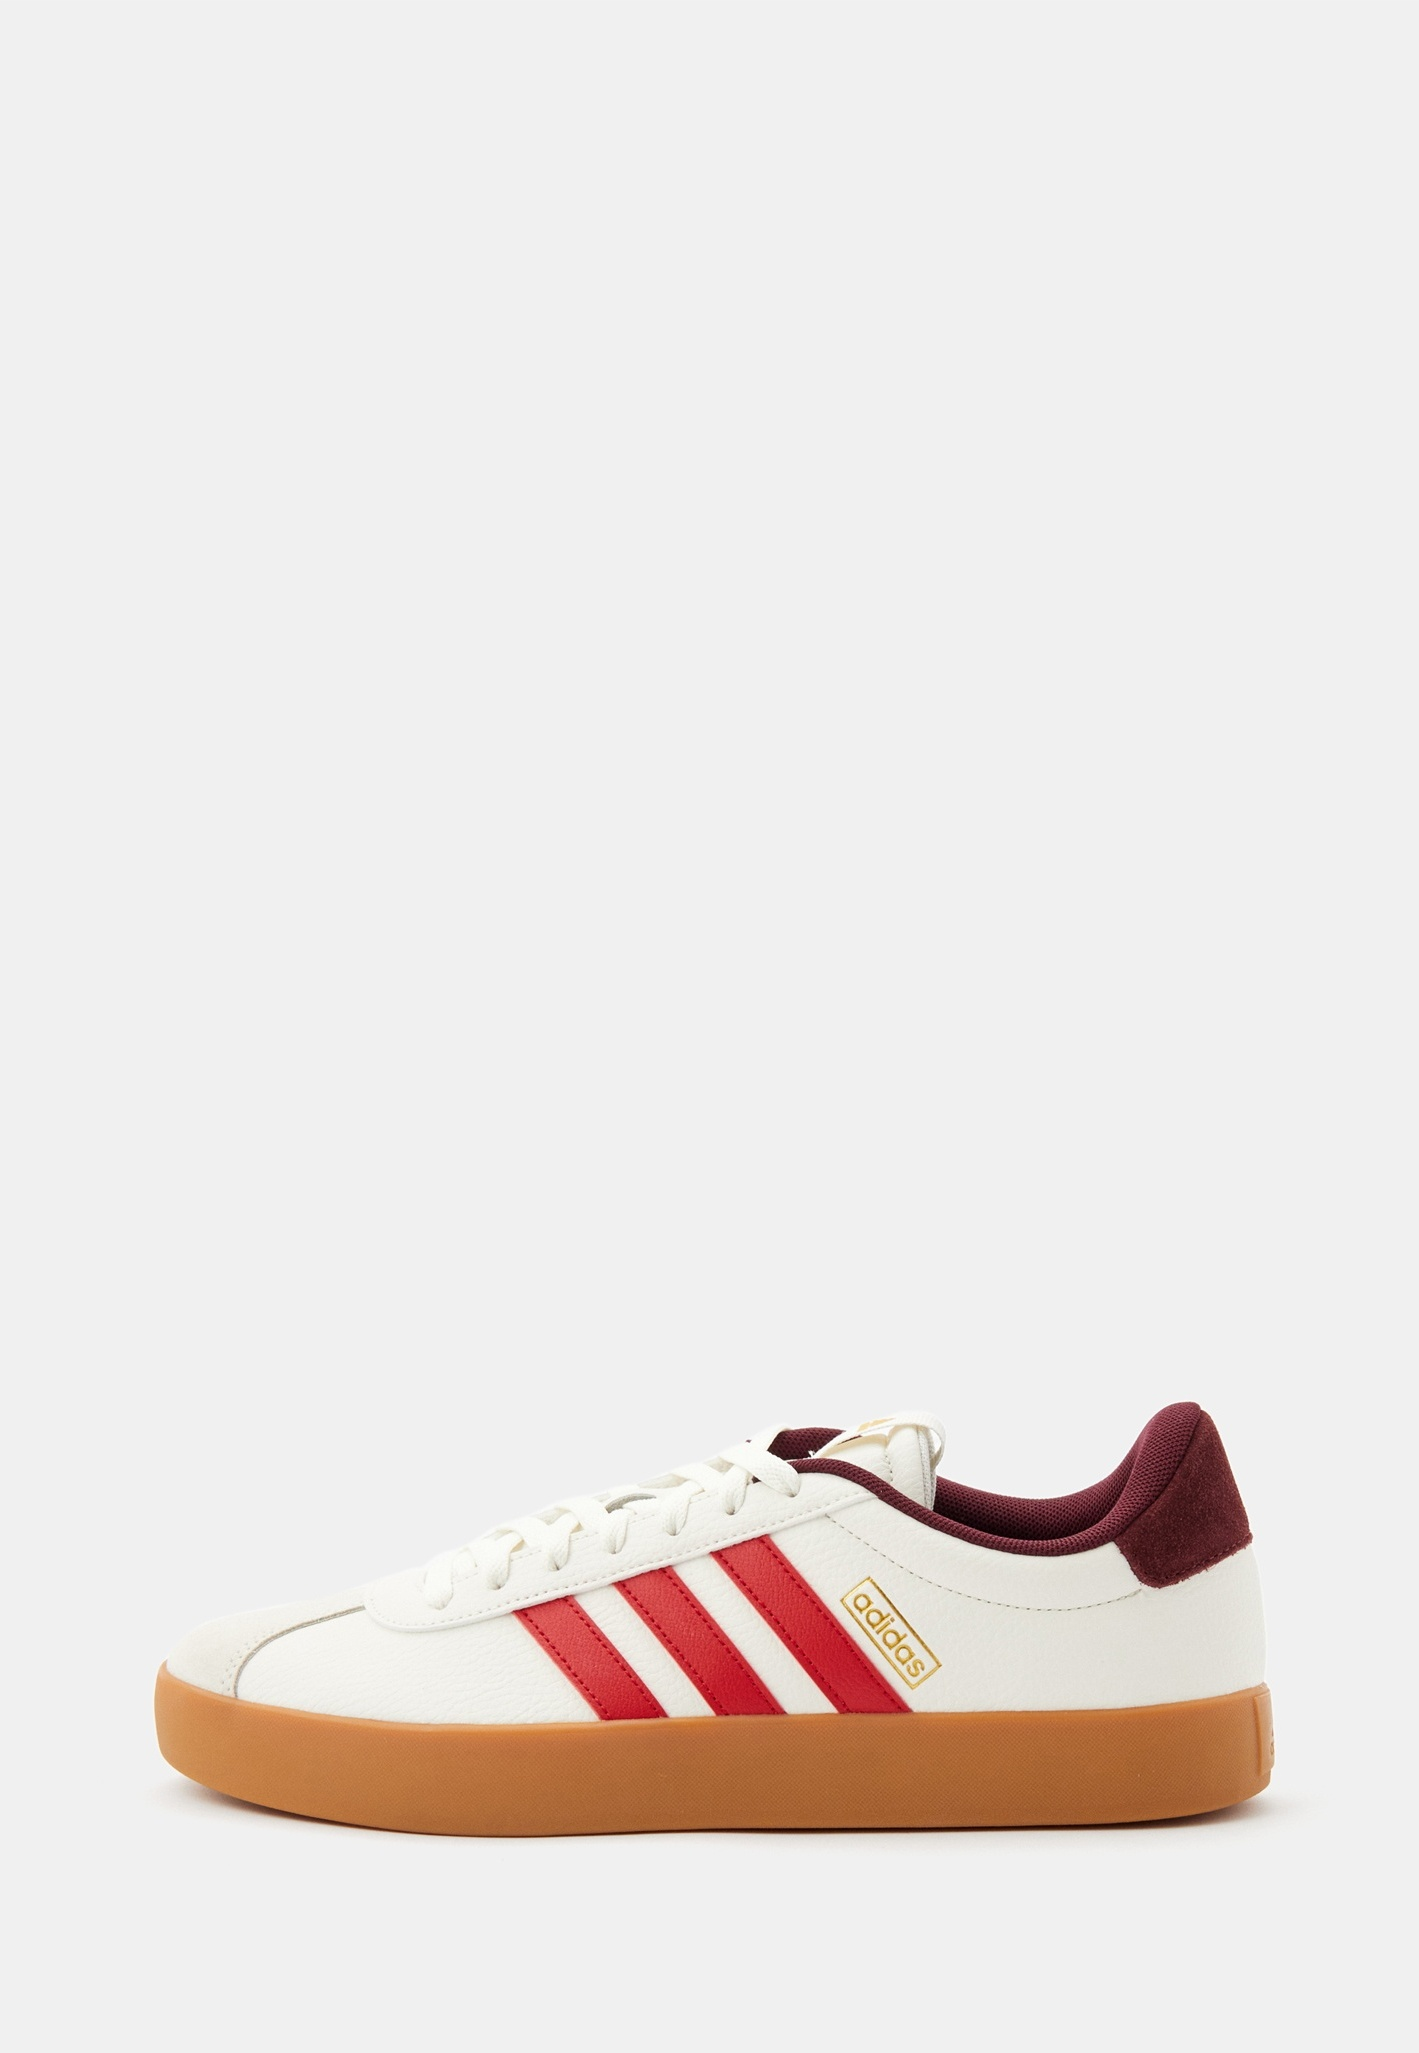

In [25]:
Image.open(image_path)

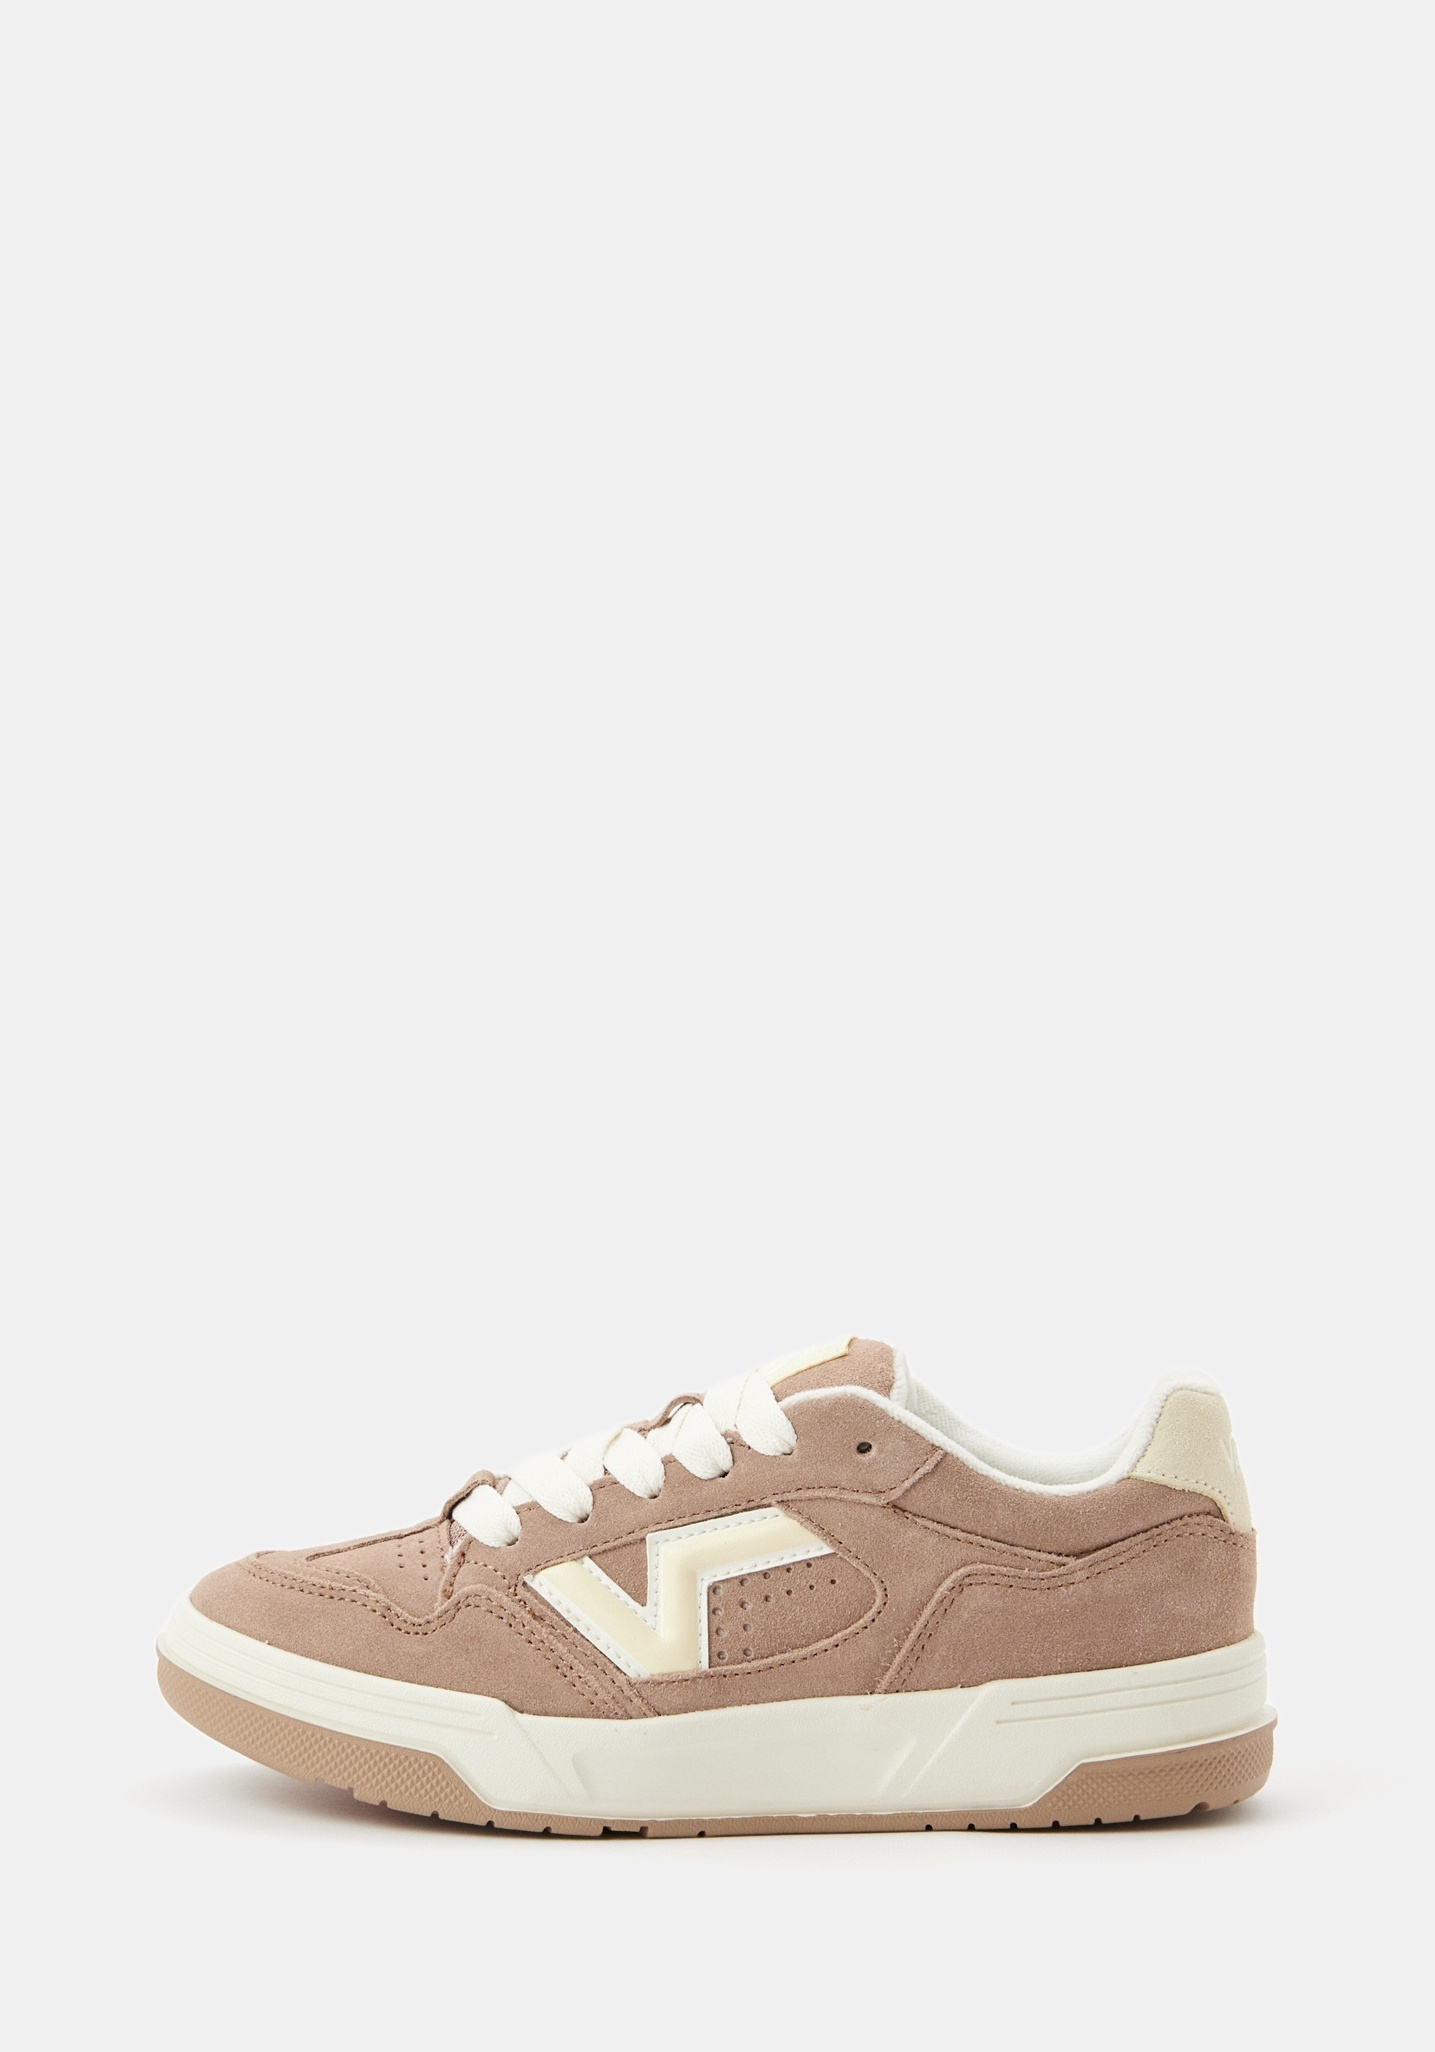

In [26]:
Image.open(PATH_TO_YOLO_OUTPUT / 'Vans Кеды Upland/clothing_0_57.jpeg')